# From an image to a RadialPaths geometry

## Author

[Rafael S. de Souza](https://rafaelsdesouza.com.br/)

## Learning goals

- inspect the background estimate and PSF-scale smoothing
- distinguish provisional and final connected support
- review centre candidates before selecting supplied centres
- construct both coordinates from the final support and centres
- measure centre-conditioned profiles of a registered tracer

## Keywords

irregular morphology, support mask, centre candidates,
support-constrained distance, radial profile

## Summary

Prepare a connected support and supplied centres from an astronomy-inspired
image, then construct both radial coordinates and measure a registered tracer.

## Resources

- [Documentation](https://rafaelsdesouza.com.br/multiradial/docs/)
- [Source](https://github.com/RafaelSdeSouza/multiradial)
- Paper/preprint: bibliographic link pending
- [Citation metadata](https://github.com/RafaelSdeSouza/multiradial/blob/main/CITATION.cff)

The first release will use a pinned Git tag for Colab installation. Until that
tag exists, execute this notebook from a local checkout with the package source
available in `src/`.

In [1]:
from pathlib import Path
import sys

source = Path("src") if Path("src/radialpaths").exists() else Path("../src")
if str(source.resolve()) not in sys.path:
    sys.path.insert(0, str(source.resolve()))

import matplotlib.pyplot as plt
import numpy as np

from radialpaths import build_geometry, radial_profile
from radialpaths.plotting import plot_centre_candidates, plot_geometry, plot_profile
from radialpaths.preprocessing import (
    estimate_background,
    finalize_support,
    find_centre_candidates,
    prepare_support,
    select_centres,
)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "savefig.dpi": 160,
})

asset_dir = Path("docs/_static/tutorials/your_own_image")
asset_dir.mkdir(parents=True, exist_ok=True)

## 1. Input image

The example is deterministic and astronomy-inspired: two compact intensity
peaks, a faint bridge, an asymmetric outer envelope, and Gaussian background
noise. The preprocessing sees only the scalar image. It is not given a
physical class for either peak.

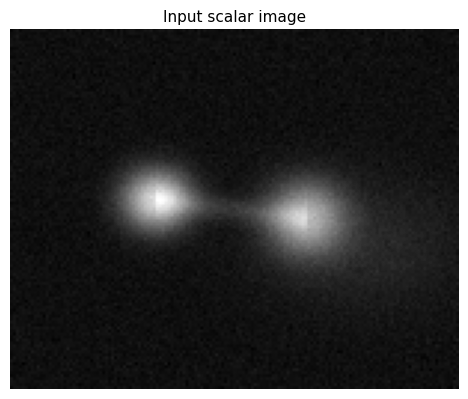

In [2]:
rng = np.random.default_rng(7319)
yy, xx = np.indices((121, 151), dtype=float)
image = 0.018 * rng.normal(size=yy.shape)
image += 0.95 * np.exp(-((yy - 57) ** 2 / (2 * 7.0**2) + (xx - 49) ** 2 / (2 * 8.0**2)))
image += 0.72 * np.exp(-((yy - 63) ** 2 / (2 * 8.5**2) + (xx - 99) ** 2 / (2 * 9.0**2)))
bridge_y = 57 + 6 * (xx - 49) / 50
bridge = (xx >= 49) & (xx <= 99)
image += 0.16 * np.exp(-((yy - bridge_y) / 4.0) ** 2) * bridge
image += 0.12 * np.exp(-((yy - 72) ** 2 / (2 * 15**2) + (xx - 119) ** 2 / (2 * 23**2)))
error = np.full(image.shape, 0.018)
psf_fwhm = 4.0  # pixels

fig, ax = plt.subplots(figsize=(6.4, 4.1))
ax.imshow(image, cmap="gray", origin="upper")
ax.set(title="Input scalar image", xticks=[], yticks=[])
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(asset_dir / "01_input_image.png", bbox_inches="tight")
plt.show()

## 2. Background and smoothing

The named `paper` preset uses the outer image border for its first estimate,
then iteratively excludes a provisional source. The reported mask shows which
pixels contribute to the final background estimate. The error image is only a
fallback if the MAD gives a non-positive scatter.

background = 0.00249
sigma_bg = 0.01891
iterations = 3


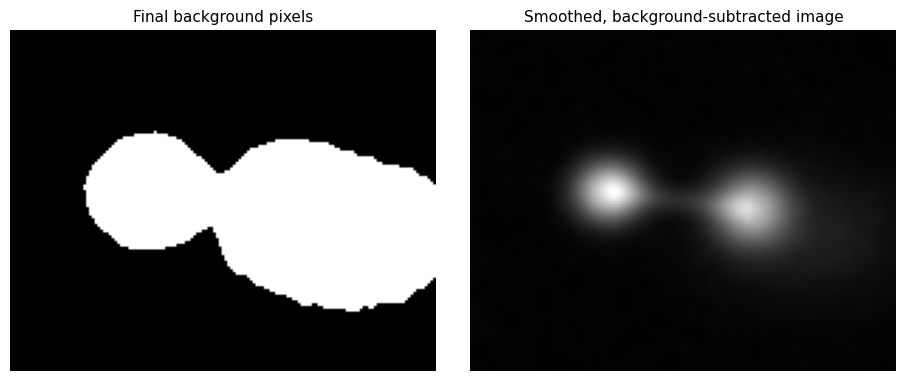

In [3]:
background = estimate_background(
    image,
    error=error,
    psf_fwhm=psf_fwhm,
    preset="paper",
)
support_stage = prepare_support(
    image,
    background=background.background,
    sigma_bg=background.sigma_bg,
    psf_fwhm=psf_fwhm,
    preset="paper",
)

print(f"background = {background.background:.5f}")
print(f"sigma_bg = {background.sigma_bg:.5f}")
print(f"iterations = {background.number_of_iterations}")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7), constrained_layout=True)
axes[0].imshow(background.background_mask, cmap="gray_r", origin="upper")
axes[0].set_title("Final background pixels")
axes[1].imshow(support_stage.smoothed - background.background, cmap="gray", origin="upper")
axes[1].set_title("Smoothed, background-subtracted image")
for ax in axes:
    ax.set(xticks=[], yticks=[])
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.savefig(asset_dir / "02_background_smoothing.png", bbox_inches="tight")
plt.show()

## 3. Provisional support

Pixels above the smoothed 1.5-sigma threshold are closed and dilated with the
paper footprints. Internal holes are not filled. Component selection is
deliberately postponed until supplied centres are known.

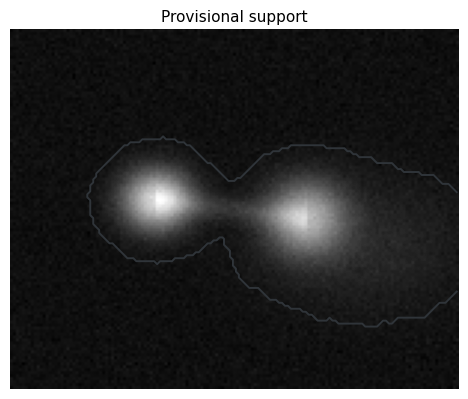

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.1))
ax.imshow(image, cmap="gray", origin="upper")
ax.contour(support_stage.provisional_support.astype(float), levels=[0.5], colors="#2F3439", linewidths=1.4)
ax.set(title="Provisional support", xticks=[], yticks=[])
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(asset_dir / "03_provisional_support.png", bbox_inches="tight")
plt.show()

## 4. Candidate centre detection and review

The same smoothed image is searched for local maxima above five background
sigmas. These are centre candidates only. Their rank records decreasing
smoothed intensity and does not encode a physical classification.

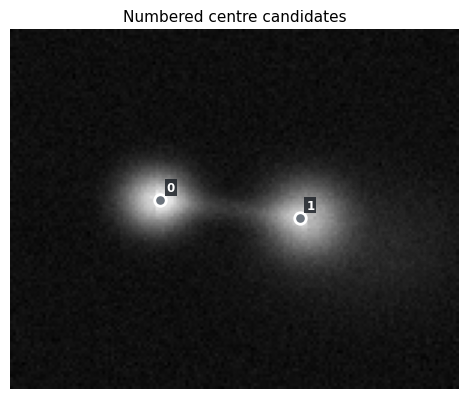

candidate | x | y | peak value | significance
        0 |  50 |  57 |    1.00966 |       53.26
        1 |  97 |  63 |    0.87037 |       45.89


In [5]:
candidates = find_centre_candidates(
    support_stage,
    psf_fwhm=psf_fwhm,
    preset="paper",
)

fig, ax = plt.subplots(figsize=(6.4, 4.1))
plot_centre_candidates(image, candidates, ax=ax)
ax.set_title("Numbered centre candidates")
fig.tight_layout()
fig.savefig(asset_dir / "04_candidate_centres.png", bbox_inches="tight")
plt.show()

print("candidate | x | y | peak value | significance")
for rank, ((row, column), peak, significance) in enumerate(
    zip(candidates.positions, candidates.peak_values, candidates.significance)
):
    print(f"{rank:9d} | {column:3d} | {row:3d} | {peak:10.5f} | {significance:11.2f}")

## 5. Select supplied centres

The reliable Colab interaction is an ordinary Python list. Here the two
brightest candidates are selected. A different analysis may use other
candidate indices or coordinates measured independently.

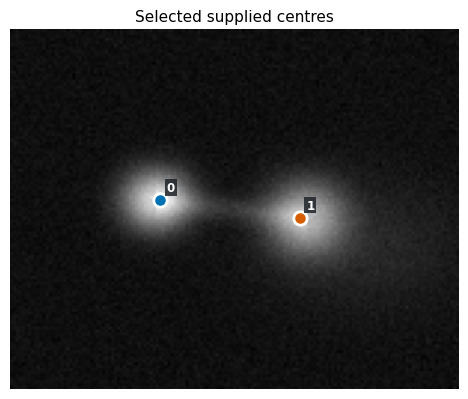

array([[57, 50],
       [63, 97]])

In [6]:
selected = [0, 1]
centres = select_centres(candidates, indices=selected)

fig, ax = plt.subplots(figsize=(6.4, 4.1))
plot_centre_candidates(image, candidates, selected=selected, ax=ax)
ax.set_title("Selected supplied centres")
fig.tight_layout()
fig.savefig(asset_dir / "05_selected_centres.png", bbox_inches="tight")
plt.show()
centres

## 6. Final connected support

The final support is the single 8-connected provisional component containing
both supplied centres. If the centres occupy different components, the
function raises an error rather than joining the image regions or dropping a
centre.

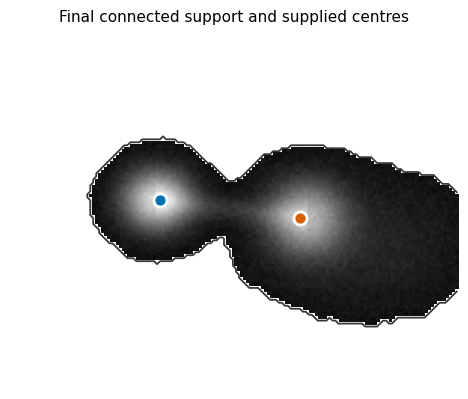

In [7]:
final = finalize_support(support_stage.provisional_support, centres, connectivity=8)

fig, ax = plt.subplots(figsize=(6.4, 4.1))
ax.imshow(np.where(final.support, image, np.nan), cmap="gray", origin="upper")
ax.contour(final.support.astype(float), levels=[0.5], colors="#343A40", linewidths=1.3)
for index, (row, column) in enumerate(centres):
    ax.scatter(column, row, s=88, c=[("#0072B2", "#D55E00")[index]], edgecolors="white", linewidths=2)
ax.set(title="Final connected support and supplied centres", xticks=[], yticks=[])
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(asset_dir / "06_final_support.png", bbox_inches="tight")
plt.show()

## 7. RadialPaths geometry

The preprocessing result is now exactly the formal input
`Omega + {c_k}`. `build_geometry()` does not repeat or hide any of the image
interpretation above.

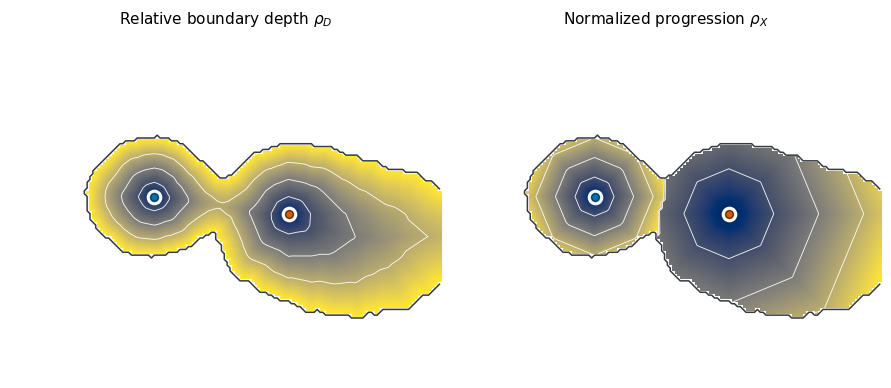

In [8]:
geometry = build_geometry(support=final.support, centres=centres)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.0), constrained_layout=True)
plot_geometry(geometry, coordinate="rho_D", ax=axes[0])
plot_geometry(geometry, coordinate="rho_X", ax=axes[1])
axes[0].set_title(r"Relative boundary depth $\rho_D$")
axes[1].set_title(r"Normalized progression $\rho_X$")
fig.savefig(asset_dir / "07_final_geometry.png", bbox_inches="tight")
plt.show()

## 8. Centre-conditioned profiles

The image is a registered scalar field on the constructed geometry. The same
geometry can now be reused for another pixel-aligned tracer without repeating
the support or centre decisions.

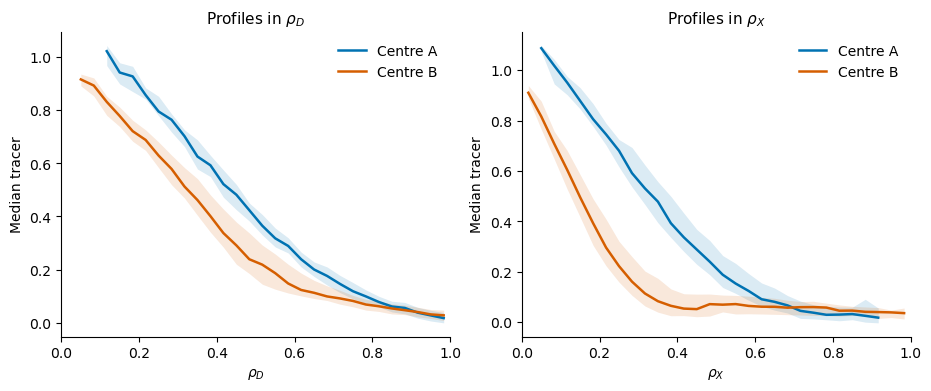

In [9]:
profile_d = radial_profile(image, geometry, coordinate="rho_D")
profile_x = radial_profile(image, geometry, coordinate="rho_X")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
plot_profile(profile_d, ax=axes[0])
plot_profile(profile_x, ax=axes[1])
axes[0].set_title(r"Profiles in $\rho_D$")
axes[1].set_title(r"Profiles in $\rho_X$")
plt.show()

## External inputs remain first-class

If a catalogue segmentation and independently measured centres already exist,
skip this preparation sequence:

```python
geometry = build_geometry(my_catalogue_mask, my_measured_centres)
```

RadialPaths supplies a reproducible reference procedure for images that lack
those inputs; it does not require that procedure for radial analysis.